In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [2]:
from torchvision import transforms

IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # important for pretrained models
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),  # keep small!
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [3]:
from torchvision import datasets

train_dir = "../datasets/train"
val_dir   = "../datasets/val"
test_dir  = "../datasets/test"

In [4]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=val_test_transforms
)

In [7]:
print(train_dataset.class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [5]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

5270
390
196


In [6]:
image, label = train_dataset[0]
print(image.shape)  # should be [3, 224, 224]
print(label)        # 0 or 1

torch.Size([3, 224, 224])
0


In [7]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16  # safe for 6GB VRAM

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                          shuffle=True, num_workers=4, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                        shuffle=False, num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
                         shuffle=False, num_workers=4, pin_memory=True)

In [14]:
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b1(pretrained=True)

# Freeze backbone initially
for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.classifier[1].in_features, 2)
)

model = model.to(device)

/home/FedoroX/Documents/Projects/PneumonicDetection/.venv/lib64/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/FedoroX/Documents/Projects/PneumonicDetection/.venv/lib64/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /home/FedoroX/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:02<00:00, 14.0MB/s]


In [15]:
import torch

class_counts = [1425, 3845]
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = weights / weights.sum()

criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

In [16]:
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scaler = GradScaler()

/tmp/ipykernel_10340/4189958798.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [17]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():  # mixed precision
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

In [18]:
def validate(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return total_loss / len(loader)

In [19]:
for param in model.features.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)  # lower LR

In [20]:
torch.cuda.empty_cache()

In [21]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

EPOCHS = 10
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # 🔍 Validation
    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # 📊 Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # 💾 Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "../models/best_model.pth")
        print("✅ Model saved!")

/tmp/ipykernel_10340/2997788316.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/10
Train Loss: 0.4786
Val Loss: 0.3622
Accuracy: 0.8744
Precision: 0.9917
Recall: 0.8351
F1 Score: 0.9067
✅ Model saved!


/tmp/ipykernel_10340/2997788316.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 2/10
Train Loss: 0.2570
Val Loss: 0.2873
Accuracy: 0.8897
Precision: 0.9919
Recall: 0.8561
F1 Score: 0.9190
✅ Model saved!


/tmp/ipykernel_10340/2997788316.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...


Epoch 8/10
Train Loss: 0.1053
Val Loss: 0.0937
Accuracy: 0.9667
Precision: 0.9928
Recall: 0.9614
F1 Score: 0.9768
✅ Model saved!


/tmp/ipykernel_10340/2997788316.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 9/10
Train Loss: 0.1077
Val Loss: 0.0878
Accuracy: 0.9641
Precision: 0.9927
Recall: 0.9579
F1 Score: 0.9750
✅ Model saved!


/tmp/ipykernel_10340/2997788316.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 10/10
Train Loss: 0.1059
Val Loss: 0.1112
Accuracy: 0.9641
Precision: 0.9963
Recall: 0.9544
F1 Score: 0.9749


In [23]:
model.load_state_dict(torch.load("../models/best_model.pth"))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 📊 Full report
print("\n=== TEST RESULTS ===")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


=== TEST RESULTS ===
              precision    recall  f1-score   support

      NORMAL       0.90      0.98      0.94        53
   PNEUMONIA       0.99      0.96      0.98       143

    accuracy                           0.96       196
   macro avg       0.94      0.97      0.96       196
weighted avg       0.97      0.96      0.96       196

Confusion Matrix:
[[ 52   1]
 [  6 137]]


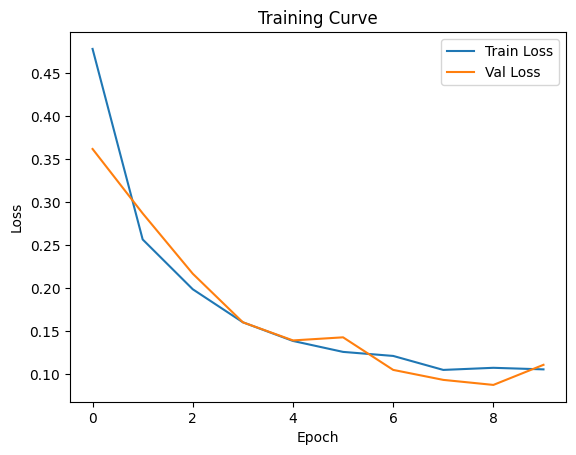

In [25]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.show()